# Calibração de modelos de crescimento tumoral

Este notebook ajusta (calibra) sete leis clássicas
de crescimento tumoral a curvas de volume × tempo de vários camundongos, compara
os modelos por critérios estatísticos e ainda testa a **capacidade de prever os
últimos pontos** de cada curva.

Ele foi escrito para ser lido **de cima para baixo**: cada bloco de explicação
vem logo antes do bloco de código que ele descreve. Rode as células em ordem.

## O que o notebook faz, em 6 passos

1. **Lê os dados** de cada grupo (uma pasta por grupo).
2. **Define 7 modelos** de crescimento (equações para a taxa $dT/dt$).
3. **Calibra cada modelo** de forma *global*: os parâmetros biológicos são
   compartilhados por todos os camundongos do grupo, mas cada camundongo tem o
   seu próprio volume inicial $T_0$.
4. **Compara os modelos** por BIC, AIC, AICc, RMSE, correlações etc.
5. **Testa a predição** removendo o último ponto de cada curva e tentando
   prevê-lo (validação *last-point*).
6. **Salva** tabela, relatório, parâmetros e figura para cada grupo.

## 1. Bibliotecas que vamos usar

- **numpy / pandas**: contas numéricas e tabelas.
- **scipy.integrate.solve_ivp**: resolve as equações diferenciais (as EDOs dos modelos).
- **scipy.optimize.minimize**: encontra os parâmetros que melhor ajustam os dados.
- **matplotlib**: gráficos.
- **tqdm**: barra de progresso.


In [31]:
from pathlib import Path
import math
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
from tqdm import tqdm

## 2. Configuração 

Aqui ficam duas coisas:

### (a) Onde estão os dados e como eles se chamam
O projeto segue **sempre a mesma convenção** (não mude isso, senão quebra):

```
<pasta_raiz>/
├── data_figB/
│   ├── data_frosberg19_fig3B_NOG_CTRL_1.csv
│   ├── data_frosberg19_fig3B_NOG_CTRL_2.csv
│   └── ...
├── data_figC/
│   └── ...
└── data_figD/
    └── ...
```

- Cada **grupo** é uma pasta cujo nome casa com `data_figX` (B, C, D, ...).
- Cada **camundongo** é um arquivo `.csv` com duas colunas: tempo e volume.
- O nome do arquivo segue `..._fig3<PAINEL>_<GRUPO>_<número>.csv`.

Para usar **outros dados** (ex.: CAR-T), mantenha essa mesma estrutura e troque
**apenas** `FILE_GLOB` para o rótulo dos seus arquivos. Tudo o mais continua igual.

### (b) Botões de velocidade × robustez
Se estiver demorando muito, **diminua** `MULTISTART_N_STARTS` e `OPT_MAXITER`.
Se quiser um ajuste mais caprichado (e mais lento), aumente-os.


In [32]:
# === (a) DADOS: mantenha a MESMA convenção de pastas e arquivos ===
DATA_ROOT   = None                 # None = detecta sozinho a pasta que contém data_figX
FOLDER_REGEX = r"data_fig[A-Z]+"   # convenção das PASTAS de grupo (não mexer)
FILE_GLOB    = "data_frosberg19_fig3*_NOG_CTRL_*.csv"   # <-- TROQUE SÓ ISTO p/ outros dados
# Exemplo para CAR-T (depois de nomear seus arquivos na mesma convenção):
#   FILE_GLOB = "data_frosberg19_fig3*_NOG_CART_*.csv"

# Captura (painel, número do camundongo) do nome do arquivo, para ordenar.
# Funciona para CTRL, CART ou qualquer rótulo, desde que o nome termine em _<n>.csv
SORT_REGEX = r"fig3([A-Z])_.*?_([0-9]+)\.csv$"

# === (b) ROBUSTEZ x VELOCIDADE ===
# Os valores abaixo priorizam um ajuste caprichado (pode levar ~minutos).
# Se quiser rodar mais rápido para testar, DIMINUA estes três números.
MULTISTART_N_STARTS = 6     # chutes iniciais por modelo (mais = mais robusto e mais lento)
OPT_MAXITER         = 250   # iterações máximas do otimizador
VALIDATION_TOP_K    = 3     # testa a predição nos K melhores modelos
USE_LAST_POINT_VALIDATION = True

# === Opções gerais ===
COUNT_T0_IN_AIC_BIC = True  # conta os T0 (1 por camundongo) na complexidade do modelo
OUTPUT_DIRNAME = "calibration_outputs_didatico"
RANDOM_SEED = 42
MODEL_SELECTION_METRIC = "BIC"   # critério principal de escolha do modelo
BOUNDARY_TOL_REL = 0.02
T0_BOUND_FRACTION_LOW  = 0.10    # T0 pode ir de 10% ...
T0_BOUND_FRACTION_HIGH = 4.0     # ... a 4x o primeiro volume observado
T0_BOUND_BUFFER = 0.0

MODELS = [
    "bertalanffy",
    "exponential",
    "gompertz",
    "linear",
    "logistic",
    "mendelsohn",
    "surface",
]

## 3. Lendo e conferindo os dados

Três funções simples:

- `read_time_volume_file`: lê um `.csv` de um camundongo. É tolerante: aceita
  vírgula, ponto-e-vírgula ou espaço como separador, ignora cabeçalho e linhas
  com `#`, e usa só as duas primeiras colunas (tempo e volume). Devolve uma
  tabela com colunas `t` (tempo) e `V` (volume), ordenada por tempo.
- `validate_datasets`: confere o básico (≥ 3 pontos, tempos crescentes, volumes
  positivos). Se algo estiver errado, avisa com mensagem clara — melhor falhar
  cedo do que calibrar lixo.
- `find_data_root` + `load_data_by_folder`: acham a pasta raiz e carregam cada
  grupo (`data_figX`) usando o `FILE_GLOB` que você configurou.


In [33]:
def read_time_volume_file(filepath):
    '''Lê um arquivo de um camundongo e devolve DataFrame com colunas t, V.'''
    with open(filepath, "r", encoding="utf-8") as f:
        sample = "".join(f.readlines()[:10])
    sep = r"[;,]" if re.search(r"[;,]", sample) else r"\s+"
    df = pd.read_csv(
        filepath, header=None, names=["t", "V"], sep=sep, engine="python",
        comment="#", skip_blank_lines=True, skipinitialspace=True, usecols=[0, 1],
    )
    df["t"] = pd.to_numeric(df["t"], errors="coerce")
    df["V"] = pd.to_numeric(df["V"], errors="coerce")
    df = df.dropna(subset=["t", "V"]).copy()
    df = df.sort_values("t").reset_index(drop=True)
    return df


def validate_datasets(datasets, filepaths):
    '''Confere requisitos mínimos de cada camundongo.'''
    for i, (df, fp) in enumerate(zip(datasets, filepaths), start=1):
        t_obs = df["t"].to_numpy(float)
        v_obs = df["V"].to_numpy(float)
        if len(t_obs) < 3:
            raise ValueError(f"Camundongo {i} ({Path(fp).name}) tem menos de 3 observações.")
        if np.any(t_obs < 0):
            raise ValueError(f"Camundongo {i} ({Path(fp).name}) tem tempos negativos.")
        if np.any(v_obs <= 0):
            raise ValueError(f"Camundongo {i} ({Path(fp).name}) tem volumes não positivos.")
        if np.any(np.diff(t_obs) <= 0):
            raise ValueError(f"Camundongo {i} ({Path(fp).name}) deve ter tempos crescentes.")


def sort_files(filepaths):
    '''Ordena por (painel, número do camundongo) extraídos do nome do arquivo.'''
    def keys(path):
        m = re.search(SORT_REGEX, Path(path).name)
        if m:
            return (m.group(1), int(m.group(2)))
        return ("Z", 10**9)
    return sorted(filepaths, key=keys)


def find_data_root():
    '''Procura a pasta que contém subpastas data_figX.'''
    candidates = [Path.cwd(), Path.cwd() / "data"]
    seen, unique = set(), []
    for p in candidates:
        p = p.resolve()
        if p not in seen:
            seen.add(p); unique.append(p)
    for root in unique:
        if root.exists() and root.is_dir() and any(
            c.is_dir() and re.fullmatch(FOLDER_REGEX, c.name) for c in root.iterdir()
        ):
            return root
    checked = ", ".join(str(p) for p in unique)
    raise FileNotFoundError(
        f"Não encontrei pastas do tipo {FOLDER_REGEX}. Locais verificados: {checked}"
    )


def load_data_by_folder(data_root=None):
    '''Carrega cada grupo (pasta data_figX) usando o FILE_GLOB configurado.'''
    data_root = find_data_root() if data_root is None else Path(data_root)
    if not data_root.exists():
        raise FileNotFoundError(f"Pasta de dados não encontrada: {data_root}")
    grouped = {}
    folders = sorted(p for p in data_root.iterdir()
                     if p.is_dir() and re.fullmatch(FOLDER_REGEX, p.name))
    for folder in folders:
        filepaths = [str(fp) for fp in folder.glob(FILE_GLOB) if fp.is_file()]
        if not filepaths:
            continue
        filepaths = sort_files(filepaths)
        datasets = [read_time_volume_file(fp) for fp in filepaths]
        validate_datasets(datasets, filepaths)
        grouped[folder.name] = {"filepaths": filepaths, "datasets": datasets}
    if not grouped:
        raise FileNotFoundError(
            f"Nenhum arquivo casando com '{FILE_GLOB}' dentro das pastas em {data_root}"
        )
    return grouped

Vamos **carregar os dados e dar uma olhada** no que entrou. Isto também serve
de teste: se a configuração estiver errada, o erro aparece aqui.

In [34]:
data_root = find_data_root() if DATA_ROOT is None else Path(DATA_ROOT)
grouped_data = load_data_by_folder(data_root)

print(f"Pasta raiz detectada: {data_root}\n")
for group_name, gd in grouped_data.items():
    print(f"Grupo '{group_name}': {len(gd['datasets'])} camundongo(s)")
    for fp, df in zip(gd["filepaths"], gd["datasets"]):
        print(f"   {Path(fp).name:45s} n={len(df):2d}  "
              f"t∈[{df['t'].min():.1f},{df['t'].max():.1f}]  "
              f"V∈[{df['V'].min():.3g},{df['V'].max():.3g}]")
    print()

Pasta raiz detectada: C:\Users\nicol\OneDrive\Área de Trabalho\notebooks_calibracao_parte_dos_dados

Grupo 'data_figB': 2 camundongo(s)
   data_frosberg19_fig3B_NOG_CTRL_1.csv          n=15  t∈[0.8,51.2]  V∈[2.1,601]
   data_frosberg19_fig3B_NOG_CTRL_2.csv          n=15  t∈[0.8,51.2]  V∈[2.1,573]

Grupo 'data_figC': 5 camundongo(s)
   data_frosberg19_fig3C_NOG_CTRL_1.csv          n=13  t∈[12.8,103.1]  V∈[0.509,167]
   data_frosberg19_fig3C_NOG_CTRL_2.csv          n=13  t∈[13.0,103.1]  V∈[0.509,158]
   data_frosberg19_fig3C_NOG_CTRL_3.csv          n=13  t∈[12.8,103.1]  V∈[0.509,118]
   data_frosberg19_fig3C_NOG_CTRL_4.csv          n=13  t∈[13.0,103.0]  V∈[0.509,81.4]
   data_frosberg19_fig3C_NOG_CTRL_5.csv          n=13  t∈[13.0,103.1]  V∈[0.065,72.3]

Grupo 'data_figD': 4 camundongo(s)
   data_frosberg19_fig3D_NOG_CTRL_1.csv          n=24  t∈[13.1,177.0]  V∈[0.061,143]
   data_frosberg19_fig3D_NOG_CTRL_2.csv          n=26  t∈[13.1,190.7]  V∈[0.061,173]
   data_frosberg19_fig3D_NOG_CTRL

## 4. Os 7 modelos de crescimento

Cada modelo é uma fórmula para a **velocidade de crescimento** do tumor,
$\dfrac{dT}{dt}$, onde $T$ é o volume e $t$ o tempo. A ideia: a partir de um
volume inicial $T_0$, a EDO "diz" como o tumor evolui.

| Modelo | $dT/dt$ | Intuição |
|---|---|---|
| **exponential** | $r\,T$ | crescimento livre, sem freio (sobe sempre) |
| **mendelsohn** | $r\,T^{b}$ | exponencial "deformado" pelo expoente $b$ |
| **logistic** | $r\,T\,(1 - T/K)$ | cresce e **satura** numa capacidade $K$ |
| **bertalanffy** | $r\,T^{2/3} - \alpha\,T$ | ganho pela superfície menos perda proporcional |
| **gompertz** | $r\,T\,\ln(K/(T+c))$ | satura em $K$, desaceleração típica de tumores |
| **linear** | $r\,T/(T+f)$ | taxa quase constante quando $T$ é grande |
| **surface** | $r\,T/(T+f)^{1/3}$ | crescimento limitado pela superfície |

> **Importante:** estes são modelos **só de
> crescimento** — são monótonos (o exponencial só sobe; logístico/gompertz
> sobem e estabilizam). Eles descrevem bem o **controle**. Se um grupo
> **responde** ao tratamento e o tumor **regride** (sobe e depois desce),
> nenhuma destas leis consegue reproduzir a queda. Aí seria preciso um modelo
> com **termo de tratamento** (assunto de outra etapa).

As funções `safe_positive` / `safe_power` são só proteções numéricas para evitar
log de zero, overflow etc.


In [35]:
def safe_positive(x, lower=1e-12, upper=1e12):
    return float(np.clip(x, lower, upper))


def safe_power(base, exponent):
    base = safe_positive(base)
    val = np.exp(np.clip(float(exponent) * np.log(base), -700, 700))
    return float(np.clip(val, 1e-300, 1e300))


def growth_term(t, T, params, model):
    '''Retorna dT/dt para o modelo escolhido.'''
    T = safe_positive(T)
    if model == "exponential":
        return params["r"] * T
    if model == "mendelsohn":
        return params["r"] * safe_power(T, params["b"])
    if model == "logistic":
        K = safe_positive(params["K"])
        return params["r"] * T * (1 - T / K)
    if model == "bertalanffy":
        return params["r"] * safe_power(T, 2 / 3) - params["alpha"] * T
    if model == "gompertz":
        K = safe_positive(params["K"]); c = max(float(params["c"]), 0.0)
        return params["r"] * T * np.log(K / safe_positive(T + c))
    if model == "linear":
        f = safe_positive(params["f"])
        return params["r"] * T / (T + f)
    if model == "surface":
        f = safe_positive(params["f"])
        return params["r"] * T / safe_power(T + f, 1 / 3)
    raise ValueError(f"Modelo desconhecido: {model}")


def rhs_growth_only(t, y, params, model):
    return [growth_term(t, y[0], params, model)]

### 4.1 Simulando uma curva

Dado $T_0$ e os parâmetros, `simulate_growth` calcula o volume previsto nos
tempos pedidos. O **exponencial** tem solução fechada ($T_0 e^{rt}$, instantâneo).
Os demais são resolvidos numericamente com `solve_ivp` (tenta o solver `LSODA`;
se ele falhar, cai para o `RK45`).


In [36]:
def simulate_growth(t_eval, T0, params, model):
    '''Devolve (tempos, volumes_previstos) para os tempos t_eval.'''
    t_eval = np.asarray(t_eval, dtype=float)

    if model == "exponential":   # solução fechada (rápida e exata)
        dt = t_eval - t_eval[0]
        y = float(T0) * np.exp(np.clip(float(params["r"]) * dt, -700, 700))
        if np.any(~np.isfinite(y)) or np.any(y <= 0):
            raise RuntimeError("Solução exponencial inválida.")
        return t_eval, y

    for method, rtol, atol in [("LSODA", 1e-5, 1e-7), ("RK45", 1e-4, 1e-6)]:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            sol = solve_ivp(
                fun=lambda t, y: rhs_growth_only(t, y, params, model),
                t_span=(float(t_eval[0]), float(t_eval[-1])),
                y0=[float(T0)], t_eval=t_eval, method=method, rtol=rtol, atol=atol,
            )
        if sol.success:
            y = sol.y[0]
            if np.all(np.isfinite(y)) and np.all(y > 0):
                return sol.t, y
    raise RuntimeError("A integração da EDO falhou em todos os solvers.")

## 5. Chutes iniciais e limites de cada parâmetro

Para o otimizador funcionar bem, damos a ele um **chute inicial** razoável e
**limites** (mínimo/máximo) para cada parâmetro. `get_model_spec` calcula isso
automaticamente a partir da escala dos seus dados (volume máximo, mediano,
duração do experimento). Assim o notebook se adapta sozinho a dados em qualquer
escala.

`get_t0_bounds` define a faixa do volume inicial $T_0$ de cada camundongo
(por padrão, de 10% a 4× o primeiro volume medido).


In [37]:
def get_global_scales(volume_arrays, time_arrays):
    all_v = np.concatenate(volume_arrays); all_t = np.concatenate(time_arrays)
    vmax = float(np.max(all_v)); vmin = float(np.min(all_v)); vmed = float(np.median(all_v))
    tspan = max(float(np.max(all_t)) - float(np.min(all_t)), 1e-6)
    typical_rate = max((vmax - vmin) / tspan, 1e-3)
    return {"vmax": vmax, "vmin": vmin, "vmed": vmed, "tspan": tspan,
            "typical_rate": typical_rate}


def get_model_spec(model_name, volume_arrays, time_arrays):
    '''Nº de parâmetros, chute inicial, limites e como converter vetor->dict.'''
    s = get_global_scales(volume_arrays, time_arrays)
    vmax = s["vmax"]; vmed = max(s["vmed"], 1.0); tspan = s["tspan"]
    rate_scale = max(s["typical_rate"], 1e-3)

    if model_name == "exponential":
        return {"n_shared": 1, "shared_names": ["r"],
                "x0_shared": np.array([min(0.1, 2.0 / tspan)]),
                "bounds_shared": [(0.0, 0.5)],
                "shared_to_params": lambda x: {"r": x[0]}}
    if model_name == "mendelsohn":
        return {"n_shared": 2, "shared_names": ["r", "b"],
                "x0_shared": np.array([min(0.05, 1.0 / tspan), 1.0]),
                "bounds_shared": [(0.0, 0.5), (0.25, 1.75)],
                "shared_to_params": lambda x: {"r": x[0], "b": x[1]}}
    if model_name == "logistic":
        return {"n_shared": 2, "shared_names": ["r", "K"],
                "x0_shared": np.array([min(0.1, 2.0 / tspan), max(1.2 * vmax, 10.0)]),
                "bounds_shared": [(0.0, 0.5), (1.01 * vmax, max(20.0 * vmax, 10.0))],
                "shared_to_params": lambda x: {"r": x[0], "K": x[1]}}
    if model_name == "bertalanffy":
        return {"n_shared": 2, "shared_names": ["r", "alpha"],
                "x0_shared": np.array([min(2.0, max(0.2, rate_scale / (vmed ** (2/3)))), 0.02]),
                "bounds_shared": [(0.0, 5.0), (0.0, 1.0)],
                "shared_to_params": lambda x: {"r": x[0], "alpha": x[1]}}
    if model_name == "gompertz":
        return {"n_shared": 3, "shared_names": ["r", "K", "c"],
                "x0_shared": np.array([min(0.1, 2.0 / tspan), max(1.2 * vmax, 10.0), 0.5 * vmed]),
                "bounds_shared": [(0.0, 0.5), (1.01 * vmax, max(25.0 * vmax, 10.0)),
                                  (0.0, max(10.0 * vmed, vmax))],
                "shared_to_params": lambda x: {"r": x[0], "K": x[1], "c": x[2]}}
    if model_name in ("linear", "surface"):
        return {"n_shared": 2, "shared_names": ["r", "f"],
                "x0_shared": np.array([max(rate_scale, 0.1), max(vmed, 1.0)]),
                "bounds_shared": [(0.0, max(20.0 * rate_scale, 10.0)),
                                  (1e-6, max(20.0 * vmax, 10.0))],
                "shared_to_params": lambda x: {"r": x[0], "f": x[1]}}
    raise ValueError(f"Modelo desconhecido: {model_name}")


def get_t0_bounds(volume_arrays):
    guesses, bounds = [], []
    for v in volume_arrays:
        v0 = float(v[0])
        lo = max(1e-6, T0_BOUND_FRACTION_LOW * v0)
        hi = max(v0 * (1.0 + T0_BOUND_BUFFER), T0_BOUND_FRACTION_HIGH * v0)
        guesses.append(v0); bounds.append((lo, hi))
    return np.array(guesses, dtype=float), bounds

## 6. Como achamos os melhores parâmetros (calibração)

**Calibração global.** O vetor de incógnitas é

$$\theta = [\underbrace{\text{parâmetros do modelo}}_{\text{iguais p/ todos}},\;
T_{0,1}, T_{0,2}, \dots, T_{0,n}]$$

ou seja, **um conjunto de parâmetros biológicos** para o grupo todo + **um $T_0$
por camundongo**. Isso assume que os animais seguem a mesma biologia, diferindo
só no tamanho inicial.

**Função objetivo.** Para um $\theta$ candidato, simulamos cada camundongo e
somamos o erro quadrático entre previsto e observado. O otimizador
(`L-BFGS-B`) procura o $\theta$ que **minimiza** esse erro.

**Multistart.** O otimizador pode cair num "vale" ruim (mínimo local). Para
evitar, tentamos a partir de vários chutes (`MULTISTART_N_STARTS`) e ficamos com
o melhor. ⚡ *Este é o principal botão de velocidade: menos chutes = mais rápido.*


In [38]:
def clip_to_bounds(x, bounds):
    x = np.asarray(x, dtype=float).copy()
    for i, (lo, hi) in enumerate(bounds):
        x[i] = np.clip(x[i], lo, hi)
    return x


def sample_param_within_bounds(rng, lo, hi):
    if lo <= 0:
        return rng.uniform(lo, hi)
    if hi / max(lo, 1e-12) >= 50:          # faixa muito ampla -> amostra em log
        return float(np.exp(rng.uniform(np.log(lo), np.log(hi))))
    return rng.uniform(lo, hi)


def generate_starting_points(base_x0, bounds, n_starts, rng):
    starts = [clip_to_bounds(base_x0, bounds)]
    base = np.asarray(base_x0, dtype=float)
    for m in [0.5, 0.8, 1.2, 1.5]:
        if len(starts) >= n_starts:
            break
        starts.append(clip_to_bounds(base * m, bounds))
    while len(starts) < n_starts:
        trial = np.array([sample_param_within_bounds(rng, lo, hi) for lo, hi in bounds])
        starts.append(clip_to_bounds(trial, bounds))
    seen, deduped = set(), []
    for x in starts:
        key = tuple(np.round(x, 10))
        if key not in seen:
            seen.add(key); deduped.append(x)
    return deduped


def objective_factory(model_name, t_list, v_list, n_shared, shared_to_params):
    big_penalty = 1e18
    def objective(theta):
        shared = theta[:n_shared]; T0_vec = theta[n_shared:]
        try:
            params = shared_to_params(shared)
            sqerr_total, n_total = 0.0, 0
            for t_obs, v_obs, T0_i in zip(t_list, v_list, T0_vec):
                if T0_i <= 0 or not np.isfinite(T0_i):
                    return big_penalty
                _, v_hat = simulate_growth(t_obs, T0_i, params, model_name)
                if np.any(~np.isfinite(v_hat)) or np.any(v_hat <= 0):
                    return big_penalty
                sqerr_total += float(np.sum((v_hat - v_obs) ** 2)); n_total += len(v_obs)
            return sqerr_total / max(n_total, 1)
        except Exception:
            return big_penalty
    return objective


def multistart_optimize(objective, x0, bounds, rng, n_starts):
    starts = generate_starting_points(x0, bounds, n_starts, rng)
    best_res, successful = None, 0
    for start in starts:
        try:
            res = minimize(objective, start, method="L-BFGS-B", bounds=bounds,
                           options={"maxiter": OPT_MAXITER, "maxfun": 5000, "maxls": 30})
        except Exception:
            continue
        if np.isfinite(res.fun):
            successful += int(bool(res.success))
            if best_res is None or res.fun < best_res.fun:
                best_res = res
    if best_res is None:
        raise RuntimeError("Todas as tentativas de otimização falharam.")
    return best_res, len(starts), successful

## 7. Métricas: como comparar os modelos

Um modelo pode ajustar melhor só porque tem mais parâmetros. Por isso usamos
**critérios de informação** que penalizam complexidade:

- **BIC** (critério principal) $= k\ln(n) - 2\,\text{LL}$ — **menor é melhor**.
- **AIC** e **AICc** (AIC corrigido para $n$ pequeno) — mesmo espírito.
- $k$ = nº de parâmetros, $n$ = nº de observações, LL = log-verossimilhança.

E métricas de **qualidade do ajuste**: RMSE, MAE, WAPE/sMAPE (erros percentuais
estáveis) e correlações/concordância PCC, CCC, ICC (quanto mais perto de 1, melhor).


In [39]:
from scipy.stats import shapiro, probplot
def aic_from_ll(ll, k):            return 2 * k - 2 * ll
def bic_from_ll(ll, k, n):         return k * np.log(n) - 2 * ll
def aicc_from_aic(aic, k, n):
    d = n - k - 1
    return aic + (2 * k * (k + 1)) / d if d > 0 else np.nan

def loglik_gaussian(y, yhat):
    resid = np.asarray(y, float) - np.asarray(yhat, float)
    var = max(np.var(resid, ddof=1) if len(resid) > 1 else np.var(resid), 1e-12)
    return -0.5 * np.sum(resid ** 2 / var + np.log(2 * np.pi) + np.log(var))

def rmse(y, yhat): return float(np.sqrt(np.mean((np.asarray(y,float)-np.asarray(yhat,float))**2)))
def mae(y, yhat):  return float(np.mean(np.abs(np.asarray(y,float)-np.asarray(yhat,float))))

def wape(y, yhat):
    y = np.asarray(y,float); yhat = np.asarray(yhat,float); d = np.sum(np.abs(y))
    return float(100*np.sum(np.abs(y-yhat))/d) if d > 0 else np.nan

def smape(y, yhat):
    y = np.asarray(y,float); yhat = np.asarray(yhat,float)
    d = np.where(np.abs(y)+np.abs(yhat) <= 1e-12, 1e-12, np.abs(y)+np.abs(yhat))
    return float(100*np.mean(2*np.abs(y-yhat)/d))

def pcc(y, yhat):
    y = np.asarray(y,float); yhat = np.asarray(yhat,float)
    return np.corrcoef(y, yhat)[0, 1] if len(y) >= 2 else np.nan

def ccc(y, yhat):
    y = np.asarray(y,float); yhat = np.asarray(yhat,float)
    if len(y) < 2: return np.nan
    cov = np.cov(y, yhat, ddof=1)[0, 1]
    d = np.var(y,ddof=1) + np.var(yhat,ddof=1) + (np.mean(y)-np.mean(yhat))**2
    return (2*cov)/d if d > 0 else np.nan

def icc_a1(y, yhat):
    y = np.asarray(y,float); yhat = np.asarray(yhat,float)
    if len(y) < 2: return np.nan
    X = np.column_stack([y, yhat]); n, k = X.shape
    mr = np.mean(X,1,keepdims=True); mc = np.mean(X,0,keepdims=True); gm = np.mean(X)
    ss_r = k*np.sum((mr-gm)**2); ss_c = n*np.sum((mc-gm)**2)
    ss_e = np.sum((X-mr-mc+gm)**2)
    df_r, df_c, df_e = n-1, k-1, (n-1)*(k-1)
    if df_r <= 0 or df_e <= 0: return np.nan
    ms_r = ss_r/df_r; ms_c = ss_c/df_c if df_c > 0 else 0.0; ms_e = ss_e/df_e
    den = ms_r + (k-1)*ms_e + (k*(ms_c-ms_e)/n)
    return (ms_r-ms_e)/den if not np.isclose(den, 0) else np.nan

def test_normality(y, yhat):
    '''Teste de Shapiro-Wilk para normalidade dos resíduos.'''
    resid = np.asarray(y, float) - np.asarray(yhat, float)
    if len(resid) < 3:
        return np.nan, np.nan
    return shapiro(resid)

def metrics_from_predictions(y, yhat, k_total):
    ll = loglik_gaussian(y, yhat); aic = aic_from_ll(ll, k_total)
    shapiro_stat, shapiro_p = test_normality(y, yhat)
    return {"ll": ll, "aic": aic, "aicc": aicc_from_aic(aic, k_total, len(y)),
            "bic": bic_from_ll(ll, k_total, len(y)),
            "mse": float(np.mean((np.asarray(y)-np.asarray(yhat))**2)),
            "rmse": rmse(y,yhat), "mae": mae(y,yhat), "wape": wape(y,yhat),
            "smape": smape(y,yhat), "pcc": pcc(y,yhat), "ccc": ccc(y,yhat),
            "icc": icc_a1(y,yhat), "shapiro_stat": shapiro_stat,
            "shapiro_p": shapiro_p, "k_total": k_total}

## 8. Juntando tudo: ajustar um modelo a um grupo

`fit_global_model` faz o ciclo completo para **um** modelo num grupo:
monta o vetor $\theta$, otimiza (multistart), simula o ajuste final de cada
camundongo e calcula as métricas. `build_diagnostics` deixa avisos quando um
parâmetro "encosta" no limite (sinal de que o modelo pode estar mal
identificado pelos dados).

> 💡 **Truque de velocidade:** `fit_global_model` aceita um `x0_override`
> (chute inicial pronto) e `n_starts`. Usamos isso na etapa de predição para
> **reaproveitar** os parâmetros já encontrados, em vez de procurar do zero.


In [40]:
def is_near_bound(value, bound, rel_tol=BOUNDARY_TOL_REL):
    lo, hi = bound
    if not np.isfinite(value) or hi <= lo: return False
    w = hi - lo
    return (value - lo) <= rel_tol*w or (hi - value) <= rel_tol*w


def build_diagnostics(model_name, params_est, T0_list, shared_bounds, t0_bounds, volume_arrays):
    notes = []; max_obs = max(float(np.max(v)) for v in volume_arrays)
    for (name, value), bound in zip(params_est.items(), shared_bounds):
        if is_near_bound(float(value), bound):
            notes.append(f"{name} no limite [{bound[0]:.4g}, {bound[1]:.4g}]")
    for idx, (val, bound) in enumerate(zip(T0_list, t0_bounds), start=1):
        if is_near_bound(float(val), bound):
            notes.append(f"T0_{idx} no limite [{bound[0]:.4g}, {bound[1]:.4g}]")
    if model_name in {"logistic","gompertz"} and params_est.get("K",0.0) > 10*max_obs:
        notes.append("K muito maior que os volumes; saturação pouco identificada")
    if model_name in {"linear","surface"} and params_est.get("f",0.0) > 10*max_obs:
        notes.append("f muito grande; modelo vira quase não-saturante")
    if model_name == "gompertz" and params_est.get("r",0.0) <= 1e-8:
        notes.append("r praticamente zero")
    if model_name == "mendelsohn":
        b = params_est.get("b", np.nan)
        if np.isfinite(b) and (b < 0.4 or b > 1.6):
            notes.append("b em região extrema")
        return notes if notes else ["sem problemas óbvios"]


def add_normality_flag(diag, metrics):
    if diag is None:
        diag = []
    p = metrics.get("shapiro_p", np.nan)
    if np.isfinite(p) and p < 0.05:
        diag.append(f"resíduos não-normais (Shapiro-Wilk p={p:.3g})")
    return diag

def fit_global_model(model_name, datasets, rng, x0_override=None, n_starts=None):
    model_name = model_name.lower()
    if n_starts is None:
        n_starts = MULTISTART_N_STARTS
    t_list = [df["t"].to_numpy(float) for df in datasets]
    v_list = [df["V"].to_numpy(float) for df in datasets]
    n_mice = len(datasets)

    spec = get_model_spec(model_name, v_list, t_list)
    n_shared = spec["n_shared"]
    bounds = spec["bounds_shared"] + list(get_t0_bounds(v_list)[1])
    T0_guess = get_t0_bounds(v_list)[0]
    x0 = np.concatenate([spec["x0_shared"], T0_guess]) if x0_override is None \
         else clip_to_bounds(x0_override, bounds)

    objective = objective_factory(model_name, t_list, v_list, n_shared, spec["shared_to_params"])
    result, n_used, n_ok = multistart_optimize(objective, x0, bounds, rng, n_starts)
    if not np.isfinite(result.fun):
        raise RuntimeError(f"Otimização falhou para {model_name}.")

    theta_hat = clip_to_bounds(result.x, bounds)
    shared_hat = theta_hat[:n_shared]; T0_hat = theta_hat[n_shared:]
    params_est = spec["shared_to_params"](shared_hat)

    fits, v_obs_all, v_fit_all = [], [], []
    for i, (t_obs, v_obs, T0_i) in enumerate(zip(t_list, v_list, T0_hat), start=1):
        t_fit, v_fit = simulate_growth(t_obs, T0_i, params_est, model_name)
        fits.append({"mouse": i, "t_obs": t_obs, "V_obs": v_obs,
                     "t_fit": t_fit, "V_fit": v_fit, "T0": T0_i})
        v_obs_all.append(v_obs); v_fit_all.append(v_fit)

    k_total = n_shared + (n_mice if COUNT_T0_IN_AIC_BIC else 0)
    metrics = metrics_from_predictions(np.concatenate(v_obs_all),
                                       np.concatenate(v_fit_all), k_total)
    diag = build_diagnostics(model_name, params_est, T0_hat, spec["bounds_shared"],
                             get_t0_bounds(v_list)[1], v_list)
    diag = add_normality_flag(diag, metrics)
    return {"model": model_name, "params_est": params_est, "T0_list": T0_hat,
            "theta_hat": theta_hat, "fits_by_mouse": fits, "metrics": metrics,
            "diagnostics": diag,
            "optimization": {"objective": float(result.fun), "success": bool(result.success),
                             "n_starts_used": n_used, "n_successful_starts": n_ok}}


def calibrate_global_model(model_name, datasets, seed):
    fit = fit_global_model(model_name, datasets, np.random.default_rng(seed))
    fit["validation"] = None
    return fit

## 9. Testando a **predição dos últimos pontos** (validação *last-point*)

1. Para cada camundongo, **escondemos o último ponto** da curva.
2. Calibramos o modelo **só com os pontos restantes**.
3. Pedimos ao modelo para **prever o ponto escondido** e comparamos com o real.

Isso mede **capacidade de previsão** (extrapolação 1 passo à frente), não só
qualidade de ajuste. Esse mecanismo é **independente do modelo e do grupo**:
funciona igual para controle, CAR-T ou qualquer outro — basta apontar os dados.

⚡ **Velocidade:** em vez de recalibrar do zero, reaproveitamos como chute
inicial os parâmetros já achados no ajuste completo (`x0_override`) e usamos
poucos `n_starts`. Mesmo resultado, bem mais rápido. E só validamos os
`VALIDATION_TOP_K` melhores modelos.


In [41]:
def build_validation_datasets(datasets):
    '''Cria, para cada camundongo, o treino (sem o último ponto) e o ponto escondido.'''
    train, holdout = [], []
    for i, df in enumerate(datasets, start=1):
        if len(df) < 4:           # precisa sobrar dados suficientes para treinar
            return None, None
        train.append(df.iloc[:-1].reset_index(drop=True))
        last = df.iloc[-1]
        holdout.append({"mouse": i, "t": float(last["t"]), "V": float(last["V"])})
    return train, holdout


def evaluate_last_point_validation(model_name, datasets, seed, warm_theta=None):
    train, holdout = build_validation_datasets(datasets)
    if train is None:
        return None
    # reaproveita parâmetros do ajuste completo como chute inicial (rápido)
    n_starts = 2 if warm_theta is not None else MULTISTART_N_STARTS
    fit = fit_global_model(model_name, train, np.random.default_rng(seed),
                           x0_override=warm_theta, n_starts=n_starts)

    y_true, y_pred, per_mouse = [], [], []
    for mf, h in zip(fit["fits_by_mouse"], holdout):
        t_eval = np.append(np.asarray(mf["t_fit"], float), h["t"])
        _, pred = simulate_growth(t_eval, float(mf["T0"]), fit["params_est"], model_name)
        v_pred = float(pred[-1])
        y_true.append(h["V"]); y_pred.append(v_pred)
        per_mouse.append({"mouse": h["mouse"], "t_holdout": h["t"],
                          "V_true": h["V"], "V_pred": v_pred,
                          "abs_error": abs(v_pred - h["V"])})
    return {"metrics": {"rmse": rmse(y_true,y_pred), "mae": mae(y_true,y_pred),
                        "wape": wape(y_true,y_pred), "smape": smape(y_true,y_pred),
                        "pcc": pcc(y_true,y_pred), "ccc": ccc(y_true,y_pred),
                        "n_holdout": len(y_true)},
            "per_mouse": per_mouse}


def attach_validation_to_top_models(results, datasets, base_seed, top_k=None):
    if top_k is None:
        top_k = VALIDATION_TOP_K
    if not USE_LAST_POINT_VALIDATION or not top_k or top_k <= 0:
        return results
    ranked = sorted(results, key=lambda x: x["metrics"]["bic"])
    selected = {r["model"] for r in ranked[:min(top_k, len(ranked))]}
    for idx, res in enumerate(results):
        if res["model"] not in selected:
            continue
        try:
            res["validation"] = evaluate_last_point_validation(
                res["model"], datasets, base_seed + 10_000 + idx,
                warm_theta=res.get("theta_hat"))
        except Exception as exc:
            res["validation"] = {"error": str(exc)}
    return results

## 10. Tabela-resumo, relatório e gráfico

- `build_summary_table`: junta tudo numa tabela ordenada por BIC, com a coluna
  `ΔBIC` (diferença para o melhor). Regra prática: $\Delta\text{BIC} < 2$ =
  "empate"; $> 10$ = evidência forte contra aquele modelo.
- `plot_fits`: um painel por camundongo, com os dados (pontos pretos) e as
  curvas de todos os modelos; o vencedor por BIC sai em traço mais grosso.
- As funções de relatório salvam `.txt` e `.csv` na pasta de saída.


In [45]:
def build_summary_table(results):
    rows = []

    for res in results:
        m = res["metrics"]
        val = res.get("validation")

        vm = (
            val.get("metrics")
            if isinstance(val, dict) and "metrics" in val
            else None
        )

        diagnostics = res.get("diagnostics") or []

        if isinstance(diagnostics, str):
            diagnostics = [diagnostics]

        rows.append({
            "model": res["model"],
            "BIC": m["bic"],
            "AIC": m["aic"],
            "AICc": m["aicc"],
            "LogLik": m["ll"],
            "RMSE": m["rmse"],
            "MAE": m["mae"],
            "WAPE (%)": m["wape"],
            "sMAPE (%)": m["smape"],
            "PCC": m["pcc"],
            "CCC": m["ccc"],
            "ICC": m["icc"],
            "CV_RMSE": np.nan if vm is None else vm["rmse"],
            "CV_MAE": np.nan if vm is None else vm["mae"],
            "diagnostics": " | ".join(diagnostics)
        })

    df = (
        pd.DataFrame(rows)
        .sort_values(MODEL_SELECTION_METRIC)
        .reset_index(drop=True)
    )

    df["ΔBIC"] = df["BIC"] - df["BIC"].min()
    df["ΔAICc"] = df["AICc"] - df["AICc"].min(skipna=True)

    return df


def sanitize_filename(name): return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(name))
def ensure_output_dir(base):
    out = Path(base) / OUTPUT_DIRNAME; out.mkdir(parents=True, exist_ok=True); return out
def get_layout(n, max_cols=3):
    if n <= 0: return 1, 1
    c = min(max_cols, n); return math.ceil(n / c), c


def format_group_report(group_name, filepaths, datasets, results, summary_df):
    L = ["="*90, f"RESULTADOS DO GRUPO: {group_name}", "="*90, "", "ARQUIVOS"]
    for i, (fp, df) in enumerate(zip(filepaths, datasets), start=1):
        L.append(f"  Camundongo {i}: {Path(fp).name} | n={len(df)} | "
                 f"t∈[{df['t'].min():.2f},{df['t'].max():.2f}] | "
                 f"V∈[{df['V'].min():.4g},{df['V'].max():.4g}]")
    L += ["", "COMPARAÇÃO DE MODELOS (ordenado por BIC)",
          summary_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"), ""]
    L.append(f"MELHOR MODELO POR {MODEL_SELECTION_METRIC}: {summary_df.iloc[0]['model']}")
    L += ["", "PARÂMETROS E DIAGNÓSTICOS"]
    for res in sorted(results, key=lambda x: x["metrics"]["bic"]):
        L.append(f"\n[{res['model'].upper()}]  objetivo={res['optimization']['objective']:.6g}")
        for name, value in res["params_est"].items():
            L.append(f"  {name:>8s} = {value:.6g}")
        for i, T0 in enumerate(res["T0_list"], start=1):
            L.append(f"  T0_camundongo_{i} = {T0:.6g}")
       
        val = res.get("validation")
        if isinstance(val, dict) and "metrics" in val:
            vm = val["metrics"]
            L.append(f"  PREDIÇÃO último ponto: RMSE={vm['rmse']:.4g} "
                     f"MAE={vm['mae']:.4g} WAPE={vm['wape']:.2f}% CCC={vm['ccc']:.3f}")
            for r in val["per_mouse"]:
                L.append(f"    Camundongo {r['mouse']}: t={r['t_holdout']:.1f} "
                         f"real={r['V_true']:.4g} previsto={r['V_pred']:.4g} "
                         f"erro={r['abs_error']:.4g}")
    return "\n".join(L)


def build_parameter_table(results):
    rows = []
    for res in results:
        base = {"model": res["model"]}
        base.update(res["params_est"])
        for i, v in enumerate(res["T0_list"], start=1):
            base[f"T0_camundongo_{i}"] = v
        rows.append(base)
    return pd.DataFrame(rows)


def write_reports(output_dir, group_name, filepaths, datasets, results, summary_df):
    sg = sanitize_filename(group_name)
    text = format_group_report(group_name, filepaths, datasets, results, summary_df)
    (output_dir / f"report_{sg}.txt").write_text(text, encoding="utf-8")
    summary_df.to_csv(output_dir / f"summary_{sg}.csv", index=False)
    build_parameter_table(results).to_csv(output_dir / f"parameters_{sg}.csv", index=False)
    return text


def plot_fits(datasets, results, group_name, output_name):
    rs = sorted(results, key=lambda x: x["metrics"]["bic"])
    best = rs[0]["model"]; n = len(datasets)
    n_rows, n_cols = get_layout(n, 3)
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(max(4.8*n_cols,6.0), max(3.8*n_rows+1.2,4.8)),
                             sharey=True, squeeze=False)
    axes = axes.ravel()
    styles = {"von bertalanffy":"-.","exponential":":","gompertz":"--",
              "linear":(0,(3,1,1,1)),"logistic":"-","mendelsohn":(0,(5,1)),
              "surface":(0,(1,1))}
    legend = {}
    for j, ax in enumerate(axes):
        if j >= n:
            ax.axis("off"); continue
        df = datasets[j]
        ax.scatter(df["t"], df["V"], color="black", s=35, zorder=3, label="Dados")
        for res in rs:
            mdl = res["model"]; fit = res["fits_by_mouse"][j]
            line, = ax.plot(fit["t_fit"], fit["V_fit"], ls=styles.get(mdl,"-"),
                            lw=2.8 if mdl==best else 1.6,
                            alpha=1.0 if mdl==best else 0.75, label=mdl.capitalize())
            legend.setdefault(mdl.capitalize(), line)
        ax.set_title(f"Camundongo {j+1}"); ax.set_xlabel("t (dias)")
        ax.grid(True, ls="--", alpha=0.35)
    axes[0].set_ylabel("Volume tumoral (mm³)")
    fig.suptitle(f"Calibração global — {group_name} | melhor: {best} | "
                 f"BIC={rs[0]['metrics']['bic']:.2f}", y=0.995)
    fig.legend(list(legend.values()), list(legend.keys()), loc="upper center",
               ncol=min(7, len(legend)), frameon=True, bbox_to_anchor=(0.5, 0.955))
    

    plt.tight_layout(rect=[0, 0, 1, 0.90])
    plt.savefig(output_name, dpi=300, bbox_inches="tight")
    plt.show(); plt.close(fig)
def plot_residual_diagnostics(results, group_name, output_name, selection_metric="bic"):
    
        '''Histograma + Q-Q plot dos resíduos do modelo vencedor.'''
    
        best = min(results, key=lambda x: x["metrics"][selection_metric])
        resid = np.concatenate([mf["V_obs"] - mf["V_fit"] for mf in best["fits_by_mouse"]])
    
        fig, axes = plt.subplots(1, 2, figsize=(9, 4))
        axes[0].hist(resid, bins=12, color="#7f77dd", edgecolor="white", density=True)
        mu, sigma = resid.mean(), resid.std(ddof=1)
        xs = np.linspace(resid.min(), resid.max(), 200)
        axes[0].plot(xs, (1/(sigma*np.sqrt(2*np.pi)))*np.exp(-0.5*((xs-mu)/sigma)**2), color="black", lw=1.5)
        axes[0].set_title("Histograma dos resíduos"); axes[0].set_xlabel("Resíduo (mm³)")
    
        probplot(resid, dist="norm", plot=axes[1])
        axes[1].set_title("Q-Q plot (normal)")
    
        _, p = shapiro(resid)
        fig.suptitle(f"{group_name} | modelo: {best['model']} | Shapiro-Wilk p={p:.3g}")
        plt.tight_layout()
        plt.savefig(output_name, dpi=300, bbox_inches="tight")
        plt.show(); plt.close(fig)

## 11. Rodar tudo

A célula abaixo executa o pipeline para **todos os grupos** encontrados:
calibra os 7 modelos, valida a predição dos melhores, imprime o relatório,
salva os arquivos e mostra a figura. Os resultados ficam na pasta
`calibration_outputs_didatico/` dentro da sua pasta de dados.


Saída em: C:\Users\nicol\OneDrive\Área de Trabalho\notebooks_calibracao_parte_dos_dados\calibration_outputs_didatico



Calibrando (data_figB): 100%|██████████| 7/7 [00:35<00:00,  5.13s/modelo]
c:\Users\nicol\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\nicol\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


RESULTADOS DO GRUPO: data_figB

ARQUIVOS
  Camundongo 1: data_frosberg19_fig3B_NOG_CTRL_1.csv | n=15 | t∈[0.79,51.24] | V∈[2.1,600.5]
  Camundongo 2: data_frosberg19_fig3B_NOG_CTRL_2.csv | n=15 | t∈[0.79,51.24] | V∈[2.1,573.2]

COMPARAÇÃO DE MODELOS (ordenado por BIC)
      model      BIC      AIC     AICc    LogLik    RMSE     MAE  WAPE (%)  sMAPE (%)    PCC    CCC    ICC  CV_RMSE   CV_MAE                                                                        diagnostics    ΔBIC   ΔAICc
bertalanffy 321.5460 315.9412 317.5412 -153.9706 40.9844 34.8127   15.5676    31.5321 0.9704 0.9674 0.9684 140.3243 139.6417                                                                                     0.0000  0.0000
 mendelsohn 324.0943 318.4895 320.0895 -155.2448 42.5191 36.1344   16.1587    35.9190 0.9753 0.9666 0.9675  54.7881  53.0609 r no limite [0, 0.5] | T0_1 no limite [0.21, 8.399] | T0_2 no limite [0.21, 8.399]  2.5483  2.5483
     linear 324.6151 319.0103 320.6103 -155.5052 43.1423 35

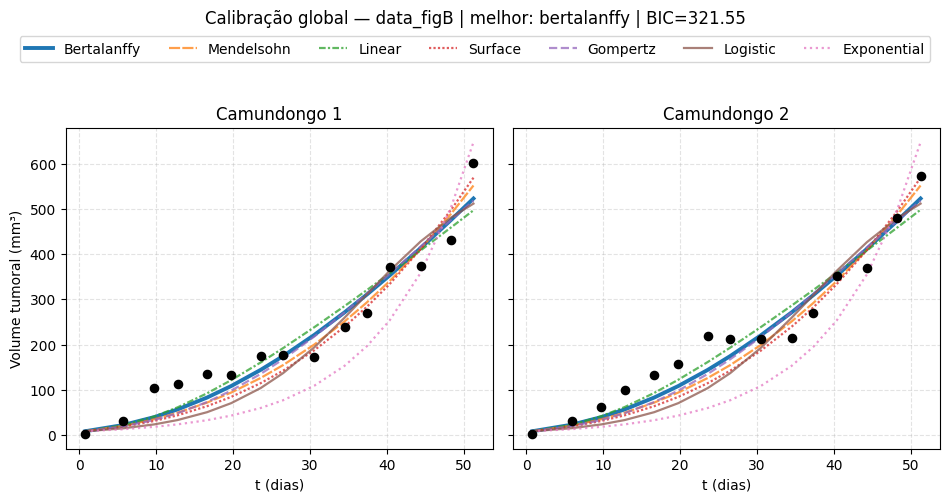

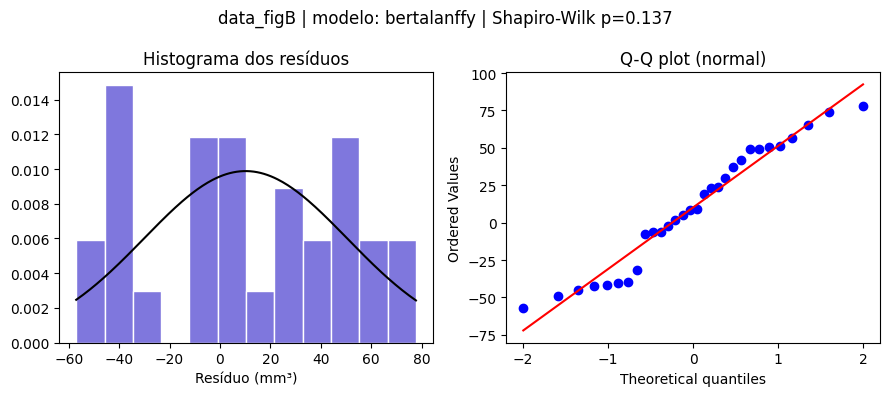


Arquivos salvos para o grupo 'data_figB'.



Calibrando (data_figC): 100%|██████████| 7/7 [03:21<00:00, 28.76s/modelo]


RESULTADOS DO GRUPO: data_figC

ARQUIVOS
  Camundongo 1: data_frosberg19_fig3C_NOG_CTRL_1.csv | n=13 | t∈[12.78,103.15] | V∈[0.5089,166.9]
  Camundongo 2: data_frosberg19_fig3C_NOG_CTRL_2.csv | n=13 | t∈[12.96,103.15] | V∈[0.5089,158.3]
  Camundongo 3: data_frosberg19_fig3C_NOG_CTRL_3.csv | n=13 | t∈[12.78,103.15] | V∈[0.5089,118.1]
  Camundongo 4: data_frosberg19_fig3C_NOG_CTRL_4.csv | n=13 | t∈[12.96,102.96] | V∈[0.5089,81.42]
  Camundongo 5: data_frosberg19_fig3C_NOG_CTRL_5.csv | n=13 | t∈[12.96,103.10] | V∈[0.06503,72.28]

COMPARAÇÃO DE MODELOS (ordenado por BIC)
      model      BIC      AIC     AICc    LogLik    RMSE     MAE  WAPE (%)  sMAPE (%)    PCC    CCC    ICC  CV_RMSE  CV_MAE                                                                                                                                                                                                              diagnostics    ΔBIC   ΔAICc
     linear 609.6196 594.3989 596.3638 -290.1995 20.9926 15.8737   27

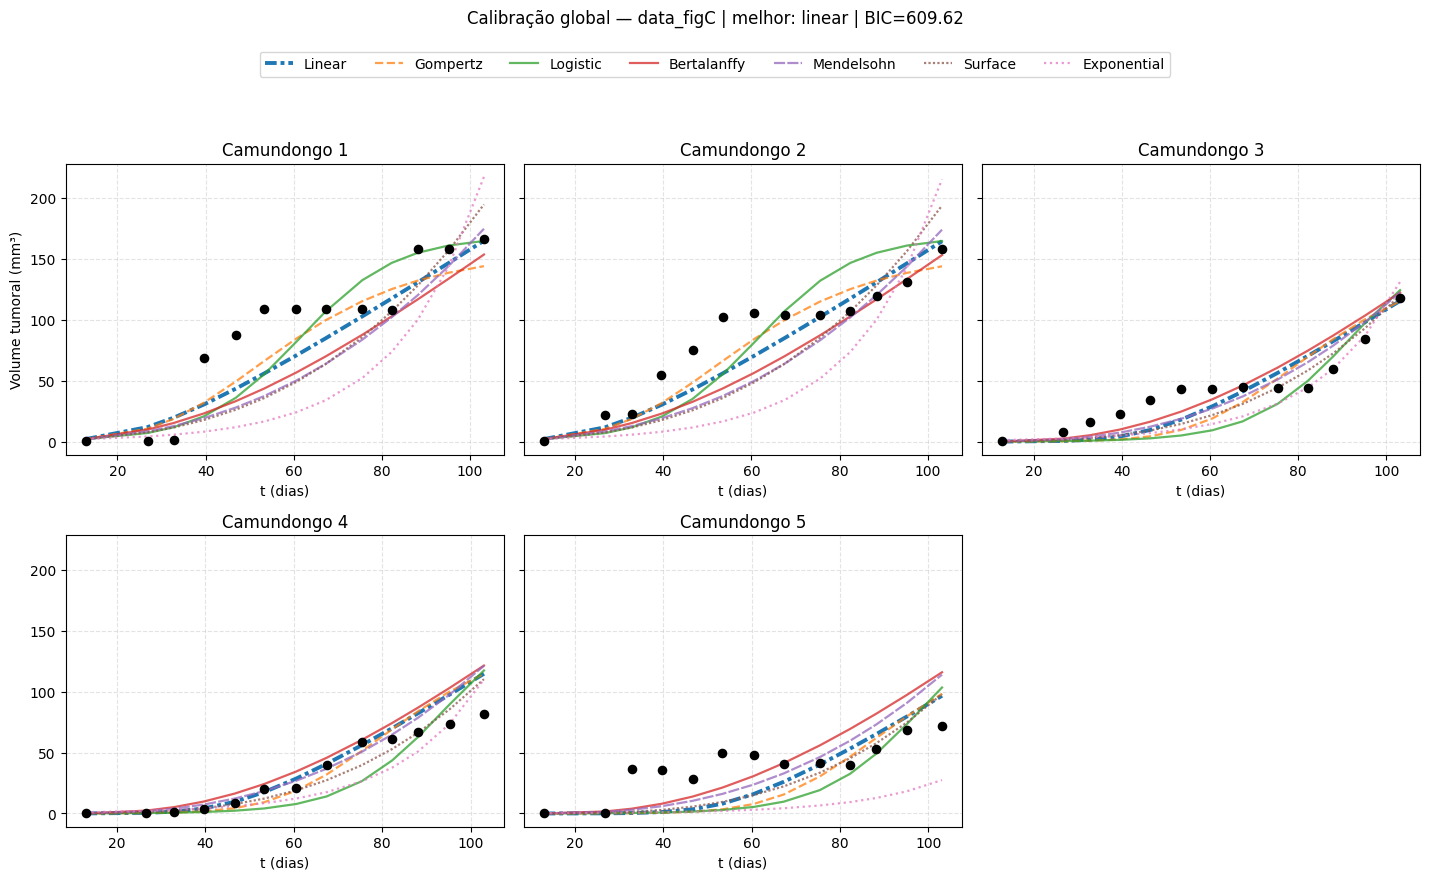

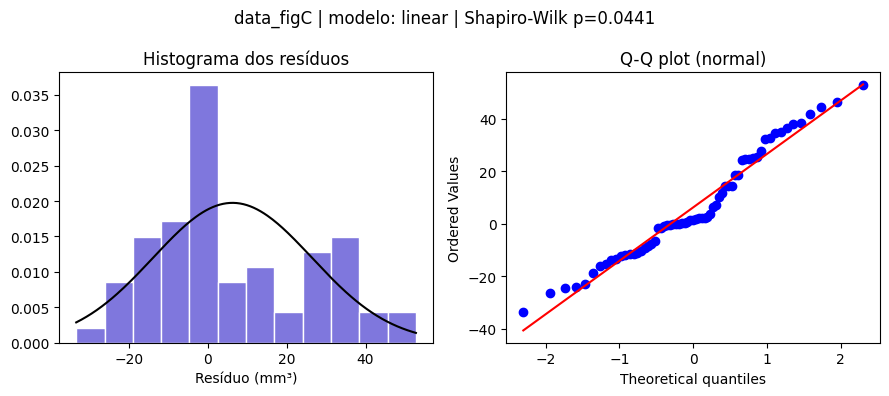


Arquivos salvos para o grupo 'data_figC'.



Calibrando (data_figD): 100%|██████████| 7/7 [01:54<00:00, 16.35s/modelo]


RESULTADOS DO GRUPO: data_figD

ARQUIVOS
  Camundongo 1: data_frosberg19_fig3D_NOG_CTRL_1.csv | n=24 | t∈[13.09,177.04] | V∈[0.06103,143.4]
  Camundongo 2: data_frosberg19_fig3D_NOG_CTRL_2.csv | n=26 | t∈[13.09,190.74] | V∈[0.06103,173.4]
  Camundongo 3: data_frosberg19_fig3D_NOG_CTRL_3.csv | n=25 | t∈[12.89,190.94] | V∈[0.9925,68.96]
  Camundongo 4: data_frosberg19_fig3D_NOG_CTRL_4.csv | n=26 | t∈[13.09,190.94] | V∈[0.06103,40.98]

COMPARAÇÃO DE MODELOS (ordenado por BIC)
      model      BIC      AIC     AICc    LogLik    RMSE     MAE  WAPE (%)  sMAPE (%)    PCC    CCC    ICC  CV_RMSE  CV_MAE                                                                                                                                                                                 diagnostics    ΔBIC   ΔAICc
     linear 871.0444 855.3537 856.2473 -421.6768 15.5708 12.0532   35.8586    92.6597 0.9267 0.9100 0.9107  30.4751 25.7771                                                                       

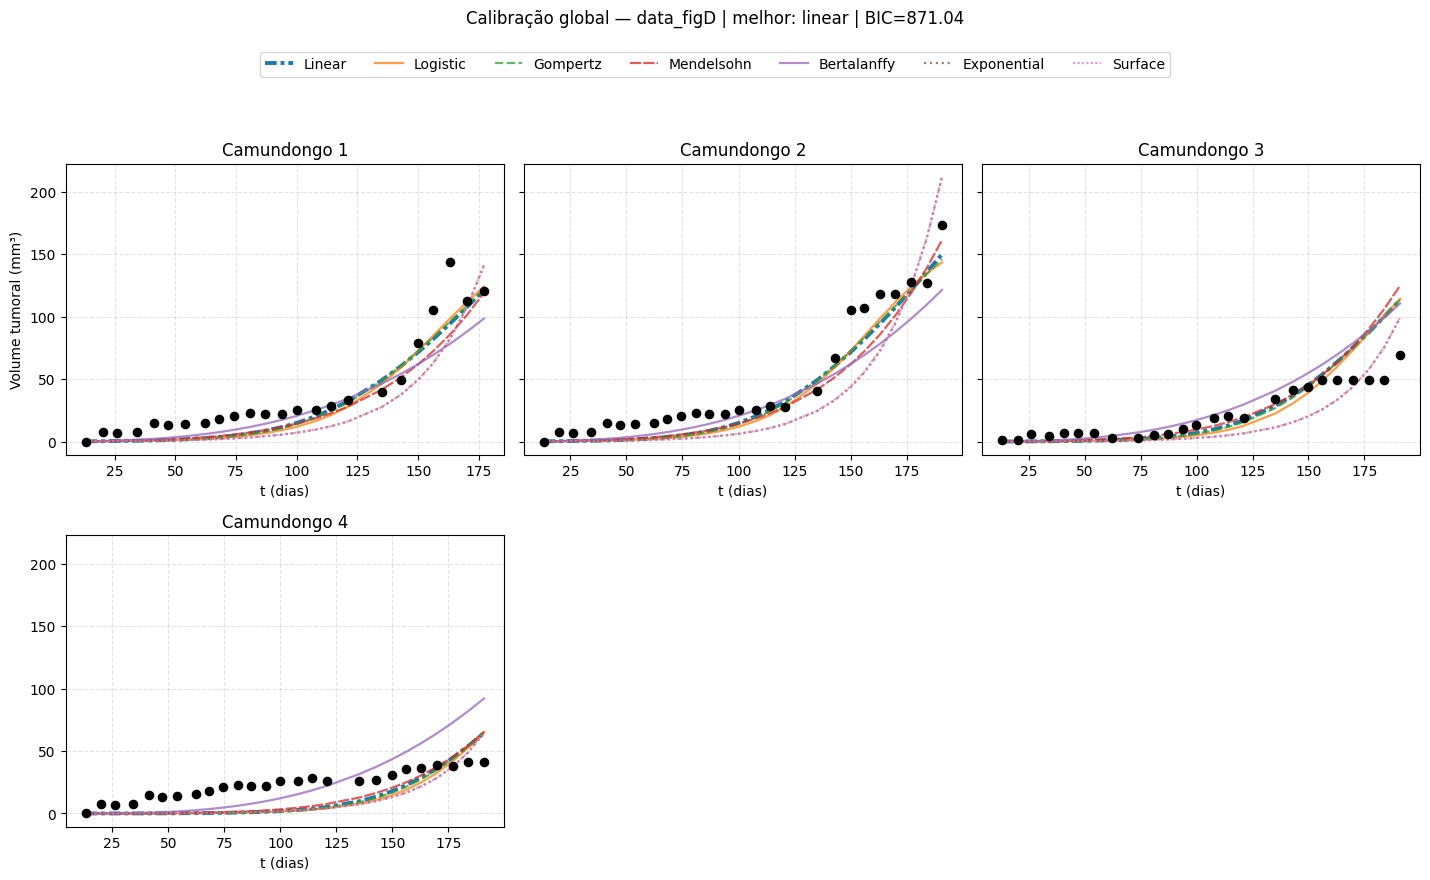

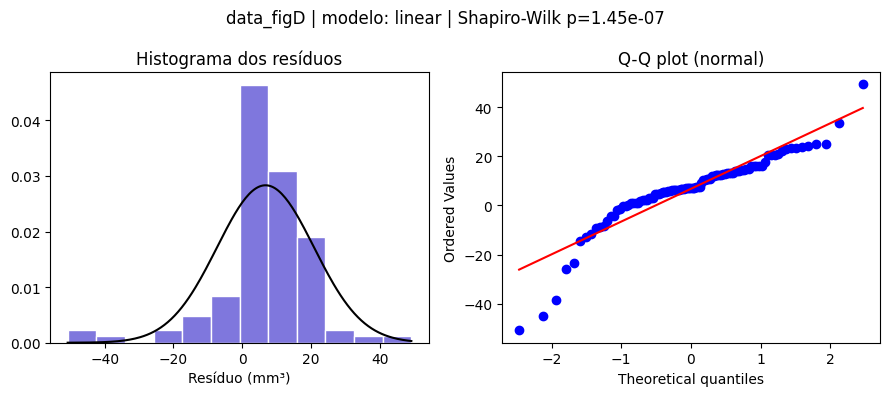


Arquivos salvos para o grupo 'data_figD'.

Concluído.


In [46]:
output_dir = ensure_output_dir(data_root)
print(f"Saída em: {output_dir}\n")

all_results = {}

for gi, (group_name, gd) in enumerate(grouped_data.items()):
    filepaths, datasets = gd["filepaths"], gd["datasets"]
    results = []

    for mi, model in enumerate(
        tqdm(
            MODELS,
            desc=f"Calibrando ({group_name})",
            unit="modelo"
        )
    ):
        try:
            results.append(
                calibrate_global_model(
                    model,
                    datasets,
                    seed=RANDOM_SEED + 1000 * gi + 100 * mi
                )
            )

        except Exception as e:
            print(
                f"[AVISO] {group_name} | {model} falhou: {e}"
            )

    if not results:
        print(
            f"[AVISO] Nenhuma calibração para {group_name}"
        )
        continue

    results = attach_validation_to_top_models(
        results,
        datasets,
        RANDOM_SEED + 1000 * gi
    )

    summary_df = build_summary_table(results)

    print(
        format_group_report(
            group_name,
            filepaths,
            datasets,
            results,
            summary_df
        )
    )

    plot_fits(
        datasets,
        results,
        group_name,
        output_dir /
        f"calibration_{sanitize_filename(group_name)}.png"
    )

    plot_residual_diagnostics(
        results,
        group_name,
        output_dir /
        f"residuals_{sanitize_filename(group_name)}.png"
    )

    write_reports(
        output_dir,
        group_name,
        filepaths,
        datasets,
        results,
        summary_df
    )

    all_results[group_name] = {
        "results": results,
        "summary": summary_df
    }

    print(
        f"\nArquivos salvos para o grupo '{group_name}'.\n"
    )

print("Concluído.")

## 12. Como usar com os **seus próprios dados** (ex.: CAR-T)

Passo a passo — **sem mexer no código**, só na configuração e nos arquivos:

1. **Nomeie e organize os arquivos** na mesma convenção:
   - uma pasta por grupo, com nome `data_figX` (ex.: `data_figB`);
   - dentro dela, um `.csv` por camundongo, com duas colunas (tempo, volume),
     no padrão `..._fig3<PAINEL>_<GRUPO>_<número>.csv`
     (ex.: `data_frosberg19_fig3B_NOG_CART_1.csv`).
2. Na seção **Configuração**, troque **só** o `FILE_GLOB` para casar com o
   rótulo dos seus arquivos, por exemplo:
   `FILE_GLOB = "data_frosberg19_fig3*_NOG_CART_*.csv"`.
3. Rode o notebook de cima para baixo. Pronto — os mesmos modelos, métricas e a
   predição do último ponto rodam para o seu grupo.

**Se estiver lento:** baixe `MULTISTART_N_STARTS` (ex.: 2), `OPT_MAXITER`
(ex.: 100) e `VALIDATION_TOP_K` (ex.: 1). Para o resultado final "caprichado",
suba esses valores de novo.

> ⚠️ **Lembrete biológico importante.** Estes 7 modelos só descrevem
> **crescimento** (curvas que sobem, eventualmente saturam). Para grupos
> tratados em que o tumor **regride**, eles vão ajustar mal — isso já é um
> resultado informativo ("crescimento puro não explica a resposta"), mas para
> *modelar o efeito do tratamento* é preciso uma equação com termo de
> tratamento, que é uma etapa à parte.

## 13. Como ler os resultados

- **Menor BIC vence.** Diferenças de `ΔBIC < 2` indicam empate técnico — vale
  olhar também AICc, RMSE e as correlações (PCC/CCC/ICC perto de 1 = bom).
- **Cuidado com diagnósticos.** Se o vencedor tem parâmetro "no limite" ou um
  $K$ gigante, a vitória pode ser por parcimônia, não por mecanismo real.
- **Predição do último ponto.** Um modelo pode ajustar bem o passado e prever
  mal o futuro — compare `RMSE` (ajuste) com `CV_RMSE` (predição).
- A escolha do melhor modelo **pode mudar de um grupo para outro**: isso é
  esperado e reflete fases/dinâmicas diferentes de crescimento.
